#### 로지스틱 회귀
: 선형방정식을 이용해서 회귀란 단어가 있지만 실제적으로 분류에 대한 확률을 계산하는 모델 

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
fish = pd.read_csv("../Data/fishes.csv")
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [3]:
# Target으로 사용될 Species의 종류 알아보기
fish.Species.unique()

array(['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt'],
      dtype=object)

In [4]:
fish.shape

(159, 6)

In [5]:
fish.describe()

,Weight,Length,Diagonal,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,28.415723,31.227044,8.970994,4.417486
std,357.978317,10.716328,11.610246,4.286208,1.685804
min,0.000000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,63.400000,68.000000,18.957000,8.142000


In [6]:
fish.Species.value_counts()

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

#### Feature와 Target Data로 정리하기

In [10]:
# Feature Data를 numpy array로 사용
fish_input = fish.iloc[:,1:].to_numpy()
fish_input[:5]

array([[242.    ,  25.4   ,  30.    ,  11.52  ,   4.02  ],
       [290.    ,  26.3   ,  31.2   ,  12.48  ,   4.3056],
       [340.    ,  26.5   ,  31.1   ,  12.3778,   4.6961],
       [363.    ,  29.    ,  33.5   ,  12.73  ,   4.4555],
       [430.    ,  29.    ,  34.    ,  12.444 ,   5.134 ]])

In [11]:
# Target Data를 numpy array로 사용 
fish_target = fish.iloc[:,0].to_numpy()
fish_target[:5]

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream'], dtype=object)

### Train과 Test로 분리 

In [12]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = \
                        train_test_split(
                            fish_input,
                            fish_target,
                            random_state=42
                        )

### 표준화 시키기
: 각 컬럼별 데이터의 크기 차이가 많지 않은 경우 사용 

In [13]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [14]:
train_scaled[:5]

array([[ 0.91965782,  0.60943175,  0.81041221,  1.85194896,  1.00075672],
       [ 0.30041219,  1.54653445,  1.45316551, -0.46981663,  0.27291745],
       [-1.0858536 , -1.68646987, -1.70848587, -1.70159849, -2.0044758 ],
       [-0.79734143, -0.60880176, -0.67486907, -0.82480589, -0.27631471],
       [-0.71289885, -0.73062511, -0.70092664, -0.0802298 , -0.7033869 ]])

In [15]:
test_scaled[:5]

array([[-0.88741352, -0.91804565, -1.03098914, -0.90464451, -0.80762518],
       [-1.06924656, -1.50842035, -1.54345461, -1.58849582, -1.93803151],
       [-0.54401367,  0.35641402,  0.30663259, -0.8135697 , -0.65388895],
       [-0.34698097, -0.23396068, -0.22320459, -0.11905019, -0.12233464],
       [-0.68475132, -0.51509149, -0.58801052, -0.8998784 , -0.50124996]])

---
### KNN을 이용한 예측

In [16]:
# n_neighbors = 3
from sklearn.neighbors import KNeighborsClassifier

In [17]:
kn = KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled, train_target)
print("Train Score :", kn.score(train_scaled, train_target))
print("Test  Score :", kn.score(test_scaled, test_target))

Train Score : 0.8907563025210085
Test  Score : 0.85


In [18]:
# kn의 분류 정보 보기
kn.classes_

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype=object)

In [19]:
# test data로 예측해 보기
kn.predict(test_scaled[:5])

array(['Perch', 'Smelt', 'Pike', 'Perch', 'Perch'], dtype=object)

#### test data의 확률값 보기

In [ ]:
import numpy as np
proba = kn.predict_proba(test_scaled[:5])
np.round(proba, decimals=4) # decimals = 4 : 소수점 4자리 까지 
# ['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish']

array([[0.    , 0.    , 1.    , 0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    , 1.    , 0.    ],
       [0.    , 0.    , 0.    , 1.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.6667, 0.    , 0.3333, 0.    , 0.    ],
       [0.    , 0.    , 0.6667, 0.    , 0.3333, 0.    , 0.    ]])

> KNN은 이웃의 갯수를 정하는 모델이다.    
현재 이웃의 갯수를 3으로 하였기 때문에 확률로 나올수 있는 경우의 수는 1/3, 2/3, 3/3이다   
=> 이 부분을 확률이라고 하기에는 좀 ....

----
#### 로지스틱 회귀를 이용한 확률 예측
- 데이터의 각 컬럼을 새로운 변수로 사용하는 다중회귀를 이용한 확률
- 회귀식을 사용하여 로지스틱 회귀라고 하나 실질적으로는 확률을 예측하는 모델임.
- 선형회귀식에서 출발하였고 딥러닝 모델의 기반임.

위의 데이터를 보면     
z = a무게 + b길이 + c대각선 + d높이 + e두께 + f 로 구성되어 있다. 
z식을 이용하면 결과값은 -무한대 ~ +무한대의 범위로 출력.     
이를 해결한 방법이 Sigmoid 함수를 사용한다.    
로지스틱 회귀를 사용할 경우에는 Sigmoid함수를 로지스틱함수라고도 표현한다.    

##### Sigmoid Graph 출력해보기

In [22]:
import matplotlib.pyplot as plt

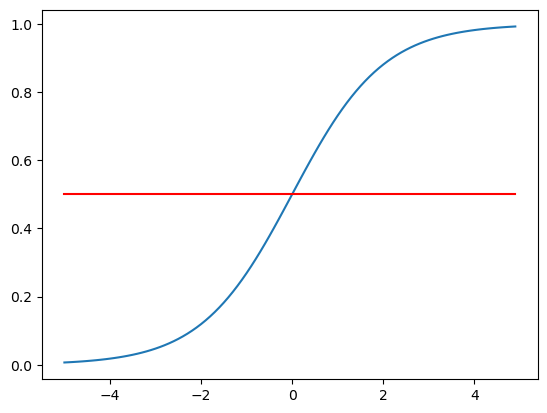

In [31]:
z = np.arange(-5, 5, 0.1)
y = np.full((100,1), 0.5)
phi = 1 / (1 + np.exp(-z)) # Sigmoid 공식 
plt.plot(z, phi)
plt.plot(z, y, c='red')
plt.show()

실질적으로 x의 값이 0이상이면 양성클래스(T,1)로 0이하이면 음성클래스로 분류하며 이를 이용하는 것이 predict함수 이다.    
각각의 확률수치를 알아보는 것이 predict_proba함수이다.    

#### 로지스회귀로 이진 분류 수행하기 

In [33]:
# 2종류의 데이터만 발췌하기
bream_smelt_indexes = (train_target == "Bream") | (train_target == "Smelt")
train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]

print(train_bream_smelt[:5])
print(target_bream_smelt[:5])

[[ 0.91965782  0.60943175  0.81041221  1.85194896  1.00075672]
 [-1.0858536  -1.68646987 -1.70848587 -1.70159849 -2.0044758 ]
 [ 0.63818253  0.56257661  0.73223951  1.64473401  0.50705737]
 [ 0.30041219  0.23459067  0.42823457  1.36042157  0.22329758]
 [ 0.9027693   0.70314202  0.88858491  1.89027545  0.85537174]]
['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [34]:
# 로지스틱 회귀 실행하기
from sklearn.linear_model import LogisticRegression

In [35]:
lr = LogisticRegression()
lr.fit(train_bream_smelt, target_bream_smelt)

LogisticRegression()

In [36]:
# 예측값 확인
lr.predict(train_bream_smelt[:5])

array(['Bream', 'Smelt', 'Bream', 'Bream', 'Bream'], dtype=object)

In [37]:
# predict_proba로 예측값 확률 분포 확인하기
lr.predict_proba(train_bream_smelt[:5])

array([[0.99760007, 0.00239993],
       [0.02737325, 0.97262675],
       [0.99486386, 0.00513614],
       [0.98585047, 0.01414953],
       [0.99767419, 0.00232581]])

In [38]:
lr.classes_

array(['Bream', 'Smelt'], dtype=object)

In [39]:
# 선형회귀식의 기울기 및 절편 확인
print(lr.coef_, lr.intercept_)

[[-0.40451732 -0.57582787 -0.66248158 -1.01329614 -0.73123131]] [-2.16172774]


In [40]:
# decision function (다중식 계산)
decisions = lr.decision_function(train_bream_smelt[:5])
print(decisions)

[-6.02991358  3.57043428 -5.26630496 -4.24382314 -6.06135688]


In [41]:
# Sigmoid 함수에 대입하여 확률값을 구성한다.
from scipy.special import expit

In [42]:
print(expit(decisions))

[0.00239993 0.97262675 0.00513614 0.01414953 0.00232581]


> 0과 1번의 분류중 1번의 기준으로 계산되며 0번의 확률은 1-1번의 확률로 사용된다. 

---
#### 로지스틱 회귀로 다중 분류 수행하기

In [45]:
lr = LogisticRegression(C=20, max_iter=1000) # 기본값 C=1, max_iter=100
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.9327731092436975
0.925


> C: 릿지규제이며 기본은 1이다. 적은수가 강한 규제를 의미한다.    
max_iter : 반복횟수, 모델의 정확성을 유지하기 위해 반복작업을 실시.

In [46]:
# test data로 예측
lr.predict(test_scaled[:5])

array(['Perch', 'Smelt', 'Pike', 'Roach', 'Perch'], dtype=object)

In [47]:
# test data로 확률 예측
proba = lr.predict_proba(test_scaled[:5])
np.round(proba, decimals=3)

array([[0.   , 0.014, 0.842, 0.   , 0.135, 0.007, 0.003],
       [0.   , 0.003, 0.044, 0.   , 0.007, 0.946, 0.   ],
       [0.   , 0.   , 0.034, 0.934, 0.015, 0.016, 0.   ],
       [0.011, 0.034, 0.305, 0.006, 0.567, 0.   , 0.076],
       [0.   , 0.   , 0.904, 0.002, 0.089, 0.002, 0.001]])

In [48]:
lr.classes_

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype=object)

In [49]:
# 사용된 다중 공식 확인
print(lr.coef_, lr.intercept_)

[[-1.50605456 -1.03747913  2.60919713  7.69422741 -1.18603342]
 [ 0.19200046 -1.99988812 -3.79617724  6.5031264  -2.00022753]
 [ 3.55793539  6.36988929 -8.52233733 -5.75397233  3.79233438]
 [-0.11453309  3.61060121  3.94464503 -3.62243904 -1.75981679]
 [-1.40843718 -6.09242191  5.28629634 -0.86696569  1.84518455]
 [-1.33419947  1.48153392  1.38217547 -5.6602348  -4.39228964]
 [ 0.61328845 -2.33223526 -0.90379939  1.70625807  3.70084846]] [-0.10345047 -0.27281218  3.24444852 -0.17565069  2.64960025 -6.72042849
  1.37829306]


### 확률 분포 검증

In [50]:
decision = lr.decision_function(test_scaled[:5])
print(np.round(decision, decimals=2))

[[ -6.51   1.04   5.17  -2.76   3.34   0.35  -0.63]
 [-10.88   1.94   4.78  -2.42   2.99   7.84  -4.25]
 [ -4.34  -6.24   3.17   6.48   2.36   2.43  -3.87]
 [ -0.69   0.45   2.64  -1.21   3.26  -5.7    1.26]
 [ -6.4   -1.99   5.82  -0.13   3.5   -0.09  -0.7 ]]


> 계산할 항목이 여러개이므로 이를 Sigmoid를 사용하며 각자의 값이 생성되어 확률의 합이 1이 넘는 경우가 발생한다.   
다중 항목인 경우에는 Softmax를 사용한다.   

In [51]:
from scipy.special import softmax
proba = softmax(decision, axis=1)
print(np.round(proba, decimals=3))

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


----
#### 확률적 경사 하강법(SGD : Stochastic Gradient Descent)
- 머신러닝에도 많이 사용하지만 실질적으로는 딥러닝에서 많이 사용한다.
- 데이터가 추가 되었을때 머신러닝 처리 방법   
1. 새로운 데이터로 모델을 추가하여 새롭게 학습하여 처리한다.     
2. 추가된 갯수만큼 기존의 데이터를 버리고 사용한다.   
3. 기존 모델을 수정하면서 사용한다. (점진적 학습방법)    

- 데이터가 추가되었을 경우에도 새로운 모델을 만들지 않고 기존의 모델을 수정하면서 사용할 있는 방법
- 머신러닝 및 딥러닝 알고리즘을 훈련하는 방법 또는 최적화 방법이지 머신러닝이고 딥러닝 모델은 아니다.  
- 확률적 <- 랜덤, 경사 <- 기울기 
- 곡선의 최적점을 찾기 위해 기울기를 조금씩 이동하면서 최적점을 찾는 방법 

- Epoch : 훈련세트를 다 사용하였을 경우의 단계 
- mini batch 경사 하강법 : hyper parameter 보통 2의 배수 사용    
- Batch 경사 하강법 : 샘플을 한번에 몽땅 꺼내서 사용하는 방법이나, 컴퓨터 메모리나 CPU에 영향을 줄 수 있어서 거의 사용 안함.   
- 보통의 확률적 경사하강법은 경사하강법이나 미니배치 경사 하강법을 사용한다.   

#### 손실함수(비용함수)
- 머신러닝 알고리즘의 에러율을 측정하는 함수 
- 손실함수 값이 적은 것이 정확도가 높은 것이다.   
- 확률적 경사하강법을 통해서 손실함수가 낮은 것을 찾는 것이다.  
- 분류함수인 경우에는 정확도를 사용하는데 이 정확도의 값은 미분할 수가 없어서(연속성이 없어서) 손실함수로 사용할 수 없다.    
- 분류함수인 경우에는 로지스틱 손실함수, 이진크로스엔트로피 손실함수를 사용한다.    

#### 확률적 경사하강법의 분류 알고리즘 적용

In [52]:
from sklearn.linear_model import SGDClassifier

In [55]:
sc = SGDClassifier(
            loss='log_loss', # 로지스틱 손실함수
            max_iter=10, # Epoch
            random_state=42
)

In [56]:
sc.fit(train_scaled, train_target)

SGDClassifier(loss='log_loss', max_iter=10, random_state=42)

In [57]:
print("Train Score:", sc.score(train_scaled, train_target))
print("Test  Score:", sc.score(test_scaled, test_target))

Train Score: 0.773109243697479
Test  Score: 0.775


> score가 별로 좋지 않고 과소적합 되어서   
partial_fit을 사용한다. (기존 w와 b의 계수값을 유지한채 update하는 방법)    
만약에 다시 fit을 사용하면 기존에 학습했던 내용을 모두 버린다.  

In [58]:
sc.partial_fit(train_scaled, train_target)
print("Train Score:", sc.score(train_scaled, train_target))
print("Test  Score:", sc.score(test_scaled, test_target))

Train Score: 0.8151260504201681
Test  Score: 0.85


> 처음의 점수보다 기존에 학습했던 내용에 새로운 학습내용을 수정하여 사용하면 점수가 증가했다.    
이와 같이 점진적으로 정확도를 높이는 방법이 확률적 경사 하강법 이다.   
처음보다는 점수가 증가했지만 아직 과소적합이다.    
약간의 차이가 나는 과대적합이 제일 좋은 방법이다.   